In [2]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('darkgrid')

print("All imports successful!")

All imports successful!


In [10]:
# Cell 2: Set working directory and load only the columns we need
import os
os.chdir(r'C:\code_projects\FinSight AI\finsight-ai')

COLUMNS_TO_LOAD = [
    'loan_status',    # Target variable source
    'annual_inc',     # Annual income → used for DSCR, Interest Coverage, Net Profit Margin
    'installment',    # Monthly loan payment → used for DSCR, Net Profit Margin
    'dti',            # Debt-to-income ratio → used directly as Leverage Ratio
    'int_rate',       # Interest rate → used for Interest Coverage
    'revol_bal',      # Revolving balance → used for Current Ratio
    'revol_util',     # Revolving utilization % → used for Current Ratio
]

DATA_PATH = r'data\raw\lending_club\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv'

print(f"Loading columns: {COLUMNS_TO_LOAD}")
print("This may take 30-60 seconds...")

df_raw = pd.read_csv(DATA_PATH, usecols=COLUMNS_TO_LOAD, low_memory=False)

print(f"\nDataset loaded successfully!")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading columns: ['loan_status', 'annual_inc', 'installment', 'dti', 'int_rate', 'revol_bal', 'revol_util']
This may take 30-60 seconds...

Dataset loaded successfully!
Shape: 2,260,701 rows × 7 columns
Memory usage: 246.0 MB


In [11]:
# Cell 3: Basic data overview
print("=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(df_raw.dtypes)

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df_raw.head()

COLUMN DATA TYPES
int_rate       float64
installment    float64
annual_inc     float64
loan_status     object
dti            float64
revol_bal      float64
revol_util     float64
dtype: object

FIRST 5 ROWS


,int_rate,installment,annual_inc,loan_status,dti,revol_bal,revol_util
0,13.99,123.03,55000.0,Fully Paid,5.91,2765.0,29.7
1,11.99,820.28,65000.0,Fully Paid,16.06,21470.0,19.2
2,10.78,432.66,63000.0,Fully Paid,10.78,7869.0,56.2
3,14.85,829.90,110000.0,Current,17.06,7802.0,11.6
4,22.45,289.91,104433.0,Fully Paid,25.37,21929.0,64.5


In [12]:
# Cell 4: Missing values analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("=" * 60)
print("MISSING VALUES SUMMARY")
print("=" * 60)
print(missing_df)
print(f"\nTotal rows: {len(df_raw):,}")

MISSING VALUES SUMMARY
             Missing Count  Missing %
dti                   1744       0.08
revol_util            1835       0.08
int_rate                33       0.00
installment             33       0.00
annual_inc              37       0.00
loan_status             33       0.00
revol_bal               33       0.00

Total rows: 2,260,701


In [13]:
# Cell 5: Statistical summary of numeric columns
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df_raw.describe().round(2)

STATISTICAL SUMMARY


,int_rate,installment,annual_inc,dti,revol_bal,revol_util
count,2260668.00,2260668.00,2.260664e+06,2258957.00,2260668.00,2258866.00
mean,13.09,445.81,7.799243e+04,18.82,16658.46,50.34
std,4.83,267.17,1.126962e+05,14.18,22948.31,24.71
min,5.31,4.93,0.000000e+00,-1.00,0.00,0.00
25%,9.49,251.65,4.600000e+04,11.89,5950.00,31.50
50%,12.62,377.99,6.500000e+04,17.84,11324.00,50.30
75%,15.99,593.32,9.300000e+04,24.49,20246.00,69.40
max,30.99,1719.83,1.100000e+08,999.00,2904836.00,892.30


LOAN STATUS DISTRIBUTION (Raw)
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

LOAN STATUS DISTRIBUTION (%)
loan_status
Fully Paid                                             47.63
Current                                                38.85
Charged Off                                            11.88
Late (31-120 days)                                      0.95
In Grace Period                                         0.37
Late (16-30 days)

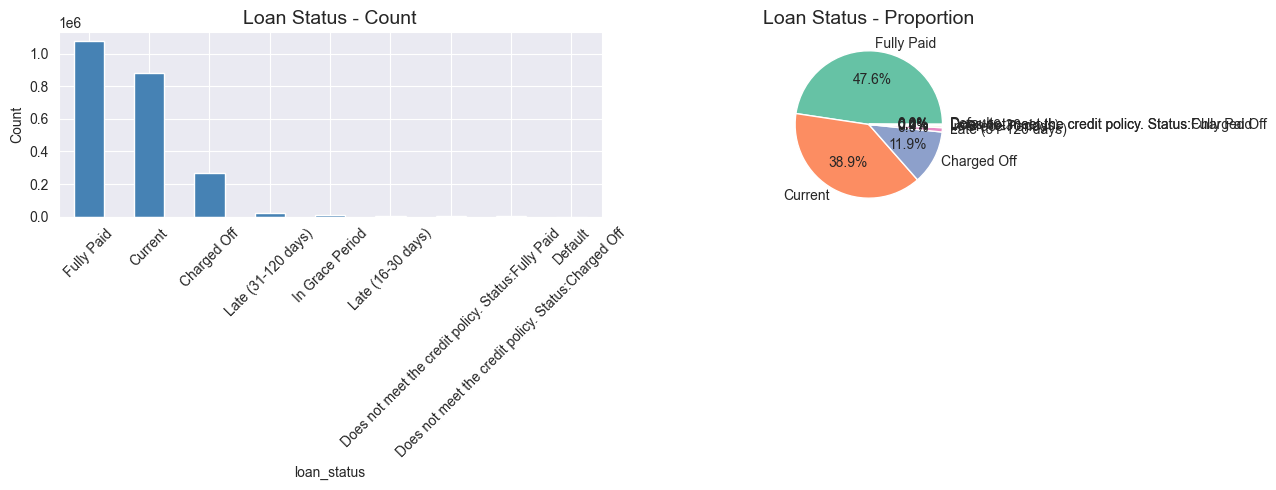


Plot saved to notebooks/loan_status_distribution.png


In [14]:
# Cell 6: Target variable - loan_status distribution
print("=" * 60)
print("LOAN STATUS DISTRIBUTION (Raw)")
print("=" * 60)
status_counts = df_raw['loan_status'].value_counts()
print(status_counts)

print("\n" + "=" * 60)
print("LOAN STATUS DISTRIBUTION (%)")
print("=" * 60)
status_pct = (status_counts / len(df_raw) * 100).round(2)
print(status_pct)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Loan Status - Count', fontsize=14)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

status_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Loan Status - Proportion', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('notebooks/loan_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to notebooks/loan_status_distribution.png")


In [15]:
# Cell 7: Create binary target variable + clean missing values
# Step 1: Keep only "Fully Paid" and "Charged Off" (drop incomplete loans)
valid_statuses = ['Fully Paid', 'Charged Off']
df = df_raw[df_raw['loan_status'].isin(valid_statuses)].copy()

# Step 2: Create binary target (0 = Fully Paid, 1 = Charged Off/Default)
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Step 3: Drop rows with missing values in our required columns
required_cols = ['annual_inc', 'installment', 'dti', 'int_rate', 'revol_bal', 'revol_util']
rows_before_drop = len(df)
df = df.dropna(subset=required_cols)
rows_after_drop = len(df)

print(f"Rows in raw dataset:        {len(df_raw):,}")
print(f"Rows after status filter:   {rows_before_drop:,}")
print(f"Rows dropped (nulls):       {rows_before_drop - rows_after_drop:,}")
print(f"Final clean rows:           {len(df):,}")
print(f"\nMissing values remaining:")
print(df[required_cols].isnull().sum())
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nDefault rate: {df['target'].mean()*100:.2f}%")
print(f"Class imbalance ratio: 1:{(1-df['target'].mean())/df['target'].mean():.1f}")

Rows in raw dataset:        2,260,701
Rows after status filter:   1,345,310
Rows dropped (nulls):       1,230
Final clean rows:           1,344,080

Missing values remaining:
annual_inc     0
installment    0
dti            0
int_rate       0
revol_bal      0
revol_util     0
dtype: int64

Target distribution:
target
0    1075772
1     268308
Name: count, dtype: int64

Default rate: 19.96%
Class imbalance ratio: 1:4.0


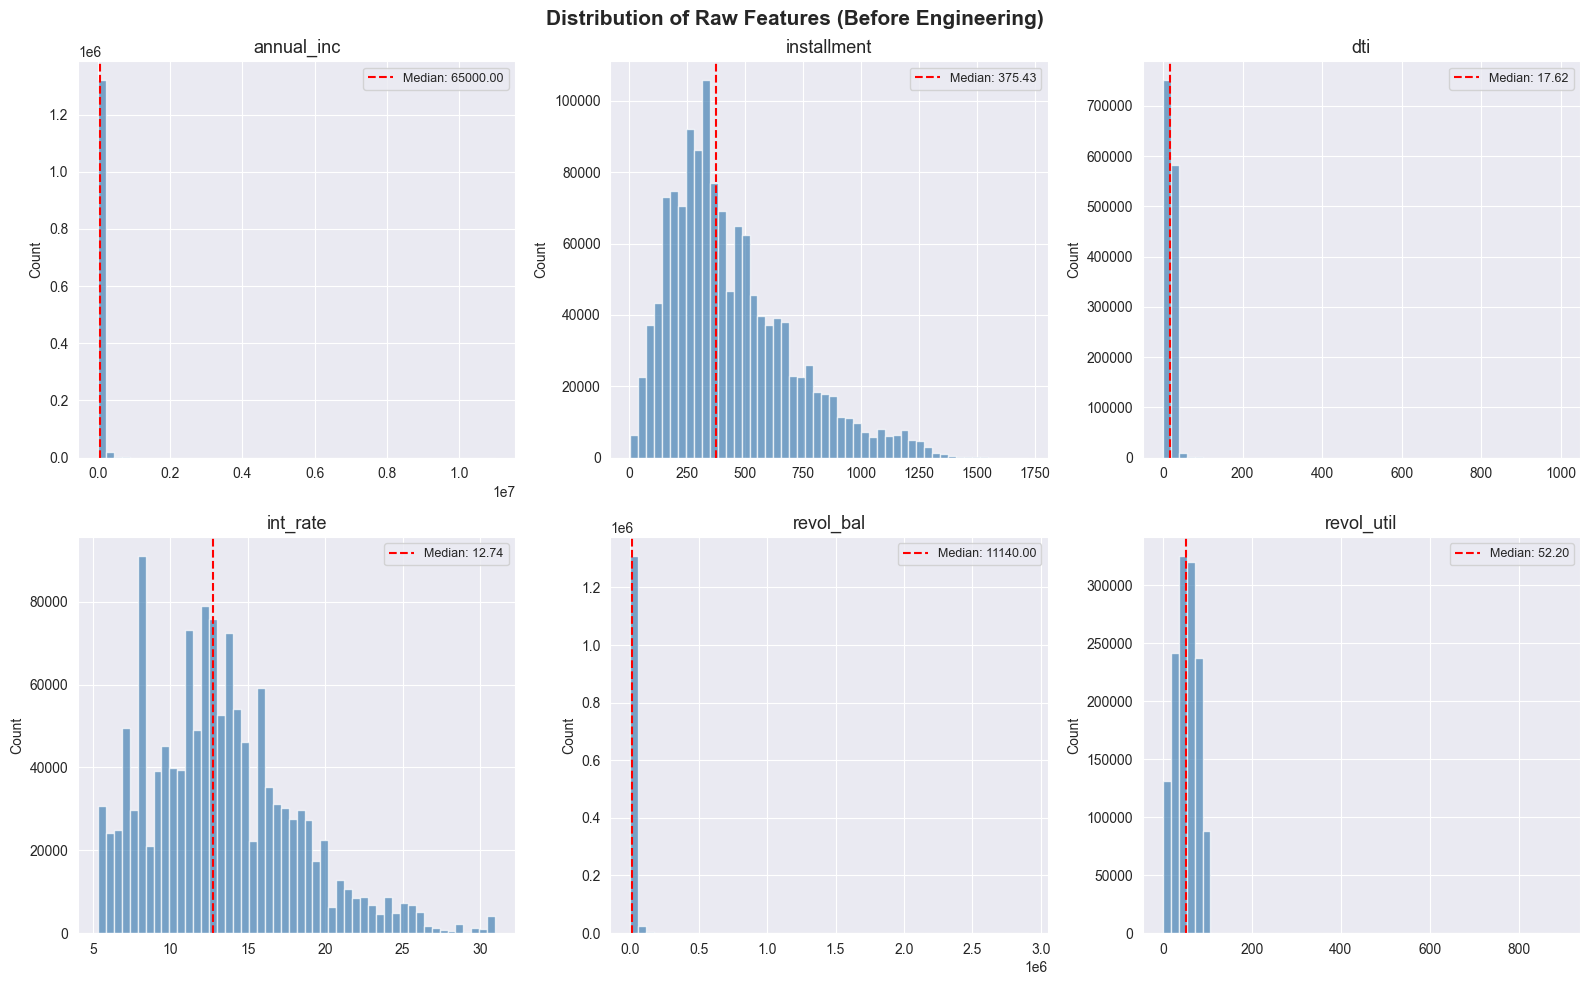

Plot saved to notebooks/raw_feature_distributions.png


In [16]:
# Cell 8: Distribution of raw features we'll use for engineering
numeric_cols = ['annual_inc', 'installment', 'dti', 'int_rate', 'revol_bal', 'revol_util']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_ylabel('Count')
    median_val = df[col].median()
    axes[i].axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Raw Features (Before Engineering)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/raw_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to notebooks/raw_feature_distributions.png")

In [17]:
# Cell 9: Outlier detection using IQR method
print("=" * 60)
print("OUTLIER ANALYSIS (IQR Method)")
print("=" * 60)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = outliers / len(df) * 100
    print(f"{col:15s} | Q1={Q1:10.2f} | Q3={Q3:10.2f} | Outliers: {outliers:,} ({outlier_pct:.2f}%)")

OUTLIER ANALYSIS (IQR Method)
annual_inc      | Q1=  45900.00 | Q3=  90000.00 | Outliers: 65,786 (4.89%)
installment     | Q1=    248.48 | Q3=    580.73 | Outliers: 41,978 (3.12%)
dti             | Q1=     11.80 | Q3=     24.06 | Outliers: 5,483 (0.41%)
int_rate        | Q1=      9.75 | Q3=     15.99 | Outliers: 24,923 (1.85%)
revol_bal       | Q1=   5951.00 | Q3=  19760.00 | Outliers: 79,608 (5.92%)
revol_util      | Q1=     33.40 | Q3=     70.70 | Outliers: 72 (0.01%)


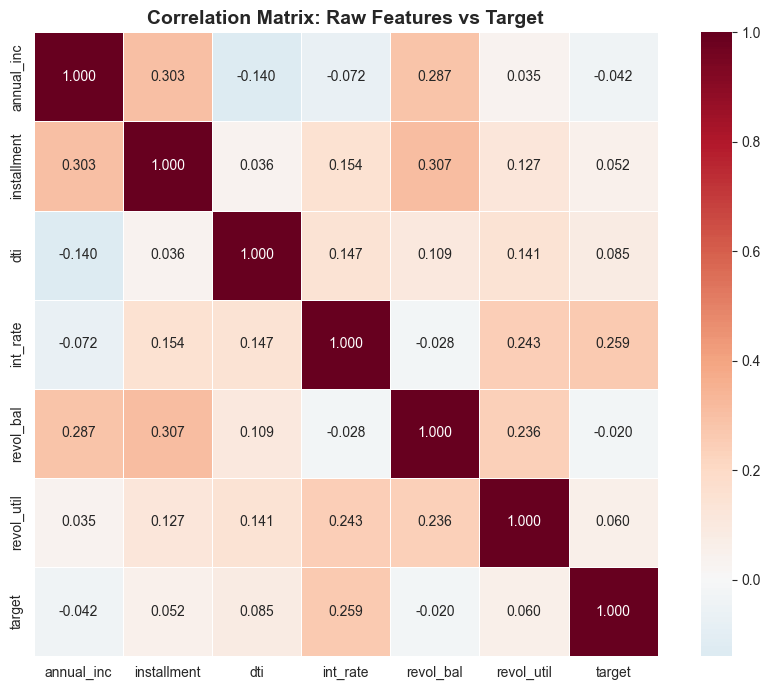

Plot saved to notebooks/correlation_matrix.png


In [18]:
# Cell 10: Correlation matrix of raw features with target
corr_cols = numeric_cols + ['target']
corr_matrix = df[corr_cols].corr().round(3)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, fmt='.3f')
plt.title('Correlation Matrix: Raw Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to notebooks/correlation_matrix.png")

In [19]:
# Cell 11: EDA Summary
print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)
print(f"""
1. Dataset size: {len(df):,} loans (after filtering to Fully Paid + Charged Off)
2. Target variable: binary (0 = Fully Paid, 1 = Charged Off/Default)
3. Default rate: {df['target'].mean()*100:.2f}% — class imbalance exists (ratio ~1:4)
4. Features to engineer: 5 financial ratios from {len(numeric_cols)} raw columns
5. Missing values: All cleaned — zero nulls remaining
6. Outliers: Present in annual_inc and revol_bal — will cap using IQR in training notebook

NEXT STEP: notebooks/02_xgboost_training.ipynb
- Engineer the 5 financial ratios
- Cap outliers using IQR method
- Train XGBoost with scale_pos_weight for class imbalance
- Generate SHAP explainability
- Save model artifacts to models/
""")

EDA SUMMARY — KEY FINDINGS

1. Dataset size: 1,344,080 loans (after filtering to Fully Paid + Charged Off)
2. Target variable: binary (0 = Fully Paid, 1 = Charged Off/Default)
3. Default rate: 19.96% — class imbalance exists (ratio ~1:4)
4. Features to engineer: 5 financial ratios from 6 raw columns
5. Missing values: All cleaned — zero nulls remaining
6. Outliers: Present in annual_inc and revol_bal — will cap using IQR in training notebook

NEXT STEP: notebooks/02_xgboost_training.ipynb
- Engineer the 5 financial ratios
- Cap outliers using IQR method
- Train XGBoost with scale_pos_weight for class imbalance
- Generate SHAP explainability
- Save model artifacts to models/

